# IRT: human vs. model vs. combined

Compares item difficulty estimated three ways -- from real human responses only, from the
37-candidate model cascade only, and from both combined -- fit with both Rasch (MLE) and
Bayesian (NUTS) IRT. Answers: do model responses track real human-derived difficulty well
enough to use as a cheap proxy?

Data: `question_difficulty_with_irt.ipynb` (human) + `run_answerer_cascade.py`/
`score_cascade_results.py` (model cascade, `cascade_results_all_scored.json`). See
`question_difficulty/docs/cascade_experiment_report.md` for the cascade results themselves.

## Contents

0. [Imports and paths](#imports)
1. [Load the 6 difficulty estimates](#load)
2. [Correlation matrix](#correlation)
3. [Model diagrams: ability, difficulty, discrimination](#scatter)
4. [Sanity check vs. the difficulty tag](#sanity-check)
5. [Manual qualitative verification](#manual)
6. [Per-candidate agreement with human difficulty vs. size/precision](#size-precision)
7. [Excluding known-bad items](#exclude-global-verif) (7.1 global-verification questions, 7.2 broken gold answers)
8. [Findings](#findings)

<a id="imports"></a>
## 0. Imports and paths

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

NOTEBOOKS_DIR = Path.cwd()
SCRIPTS_DIR = NOTEBOOKS_DIR.parent / "scripts"
assert SCRIPTS_DIR.exists()

<a id="load"></a>
## 1. Load the 6 difficulty estimates

Each is item_id -> difficulty (higher = harder). Rasch difficulties come from `fit_rasch()` (MLE point estimate); Bayesian from `fit_bayesian_irt()` (posterior mean, 3PL with a fixed 0.25 guessing floor). "model" = the 37-candidate answerer cascade (question_difficulty/docs/cascade_experiment_report.md); "combined" = human buckets + model candidates fit together as one set of "persons".

In [2]:
DIFFICULTY_FILES = {
    ("human", "rasch"): NOTEBOOKS_DIR / "irt_rasch_difficulty_cache.json",
    ("human", "bayesian"): SCRIPTS_DIR / "irt_bayesian_human_only_difficulty.json",
    ("model", "rasch"): SCRIPTS_DIR / "irt_rasch_model_only_difficulty.json",
    ("model", "bayesian"): SCRIPTS_DIR / "irt_bayesian_model_only_difficulty.json",
    ("combined", "rasch"): SCRIPTS_DIR / "irt_rasch_combined_difficulty.json",
    ("combined", "bayesian"): SCRIPTS_DIR / "irt_bayesian_combined_difficulty.json",
}

difficulty = {key: json.loads(path.read_text()) for key, path in DIFFICULTY_FILES.items()}
for (source, method), d in difficulty.items():
    print(f"{source:10s} {method:10s} {len(d)} items")

# Common items across all 6 (all should be the same 1296, but intersect to be safe)
common_items = set.intersection(*(set(d.keys()) for d in difficulty.values()))
print(f"\ncommon items across all 6: {len(common_items)}")

human      rasch      1230 items
human      bayesian   1230 items
model      rasch      1230 items
model      bayesian   1230 items
combined   rasch      1230 items
combined   bayesian   1230 items

common items across all 6: 1230


<a id="correlation"></a>
## 2. Correlation matrix

Pearson correlation between every pair of the 6 difficulty estimates, restricted to the common items. High human-vs-model correlation would mean the cheap model cascade tracks real human difficulty well; low would mean it doesn't.

In [3]:
items_sorted = sorted(common_items)
labels = [f"{s}_{m}" for s, m in difficulty]
matrix = np.zeros((len(labels), len(labels)))
for i, key_i in enumerate(difficulty):
    vals_i = np.array([difficulty[key_i][it] for it in items_sorted])
    for j, key_j in enumerate(difficulty):
        vals_j = np.array([difficulty[key_j][it] for it in items_sorted])
        matrix[i, j] = pearsonr(vals_i, vals_j)[0]

corr_df = pd.DataFrame(matrix, index=labels, columns=labels).round(3)
corr_df

,human_rasch,human_bayesian,model_rasch,model_bayesian,combined_rasch,combined_bayesian
human_rasch,1.000,0.997,0.274,0.288,0.382,0.405
human_bayesian,0.997,1.000,0.274,0.288,0.382,0.405
model_rasch,0.274,0.274,1.000,0.941,0.992,0.937
model_bayesian,0.288,0.288,0.941,1.000,0.942,0.991
combined_rasch,0.382,0.382,0.992,0.942,1.000,0.952
combined_bayesian,0.405,0.405,0.937,0.991,0.952,1.000


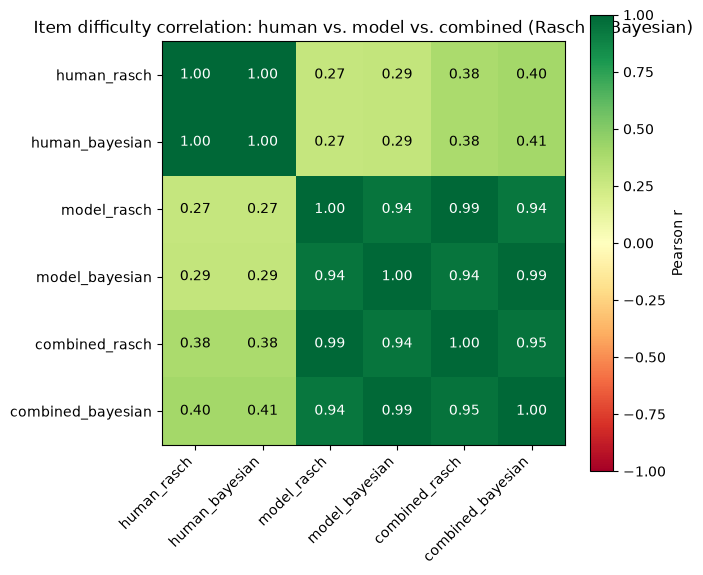

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(matrix[i,j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.title("Item difficulty correlation: human vs. model vs. combined (Rasch + Bayesian)")
plt.tight_layout()
plt.show()

<a id="scatter"></a>
## 3. Model diagrams: ability, difficulty, discrimination

The human-vs-model scatter just visualizes the correlation number already in §2 -- not much more to read there. These three are more informative, model-side only (the model-only Bayesian 3PL fit, which is the only one with a discrimination parameter -- Rasch is 1PL, no alpha):

- **Ability vs. accuracy**: does the fitted ability ranking actually match real performance?
- **Difficulty vs. discrimination**: which items are good at separating strong models from weak ones?
- **Item characteristic curves (ICC)**: for a few representative items, P(correct) as a function of model ability -- the textbook IRT diagnostic. Curve steepness = discrimination; curve position (left/right) = difficulty.

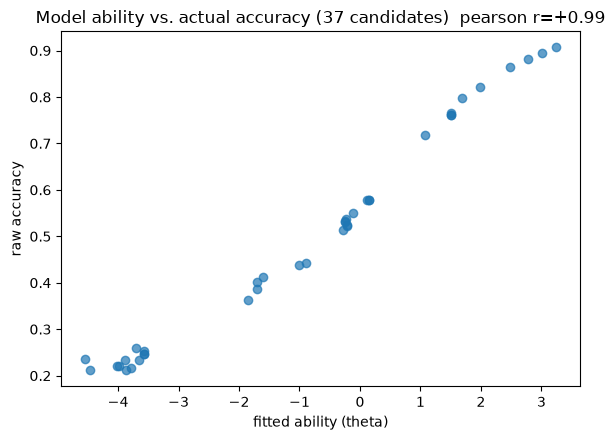

In [5]:
# Ability vs. accuracy: does fitted ability match real performance?
model_ability = json.loads((SCRIPTS_DIR / "irt_bayesian_model_only_ability.json").read_text())
cascade_results = json.loads((SCRIPTS_DIR / "cascade_results_all_scored.json").read_text())

correct_count, total_count = {}, {}
for row in cascade_results.values():
    for name, ans in row["answers"].items():
        total_count[name] = total_count.get(name, 0) + 1
        correct_count[name] = correct_count.get(name, 0) + ans["is_correct"]
accuracy = {name: correct_count[name] / total_count[name] for name in total_count}

names = list(model_ability.keys())
theta_vals = np.array([model_ability[n] for n in names])
acc_vals = np.array([accuracy[n] for n in names])
r, _ = pearsonr(theta_vals, acc_vals)

plt.figure(figsize=(6, 4.5))
plt.scatter(theta_vals, acc_vals, alpha=0.7)
plt.xlabel("fitted ability (theta)")
plt.ylabel("raw accuracy")
plt.title(f"Model ability vs. actual accuracy (37 candidates)  pearson r={r:+.2f}")
plt.tight_layout()
plt.show()

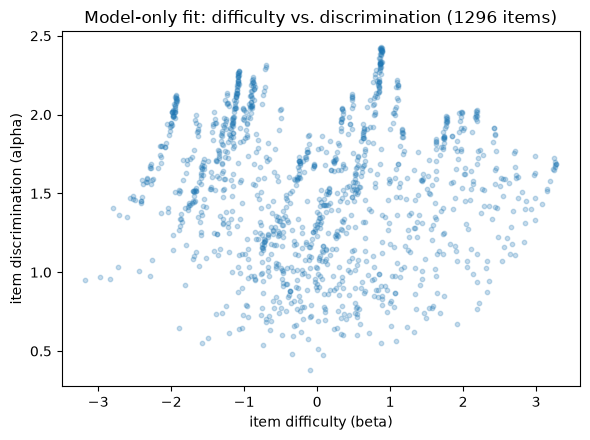

In [6]:
# Difficulty vs. discrimination: which items best separate strong from weak models?
model_discrimination = json.loads((SCRIPTS_DIR / "irt_bayesian_model_only_discrimination.json").read_text())
model_difficulty_bayes = difficulty[("model", "bayesian")]

diff_vals = np.array([model_difficulty_bayes[it] for it in items_sorted])
disc_vals = np.array([model_discrimination[it] for it in items_sorted])

plt.figure(figsize=(6, 4.5))
plt.scatter(diff_vals, disc_vals, alpha=0.25, s=10)
plt.xlabel("item difficulty (beta)")
plt.ylabel("item discrimination (alpha)")
plt.title("Model-only fit: difficulty vs. discrimination (1296 items)")
plt.tight_layout()
plt.show()

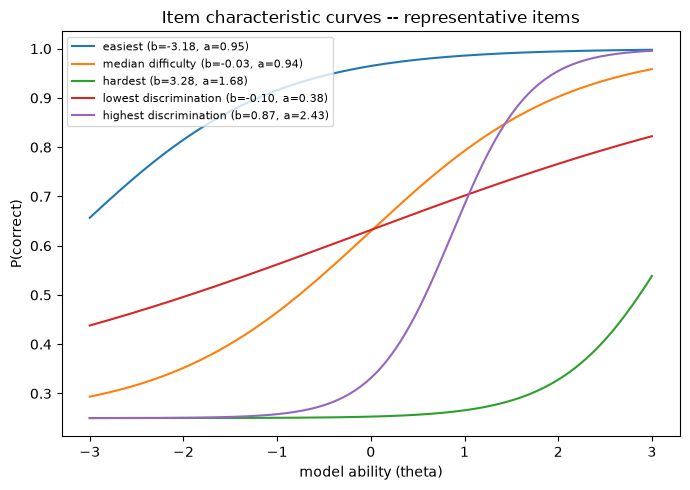

In [7]:
# Item characteristic curves -- a few representative items
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

sorted_by_diff = sorted(items_sorted, key=lambda it: model_difficulty_bayes[it])
sorted_by_disc = sorted(items_sorted, key=lambda it: model_discrimination[it])
picks = {
    "easiest": sorted_by_diff[0],
    "median difficulty": sorted_by_diff[len(sorted_by_diff) // 2],
    "hardest": sorted_by_diff[-1],
    "lowest discrimination": sorted_by_disc[0],
    "highest discrimination": sorted_by_disc[-1],
}

theta_range = np.linspace(-3, 3, 200)
plt.figure(figsize=(7, 5))
for label, it in picks.items():
    beta, alpha = model_difficulty_bayes[it], model_discrimination[it]
    p = 0.25 + 0.75 * sigmoid(alpha * (theta_range - beta))
    plt.plot(theta_range, p, label=f"{label} (b={beta:.2f}, a={alpha:.2f})")
plt.xlabel("model ability (theta)")
plt.ylabel("P(correct)")
plt.title("Item characteristic curves -- representative items")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Uncertainty

How confident is the model-only Bayesian fit about each estimate? Two views: spread of posterior std across all 1296 items (difficulty), and human-only vs. model-only posterior std across persons (ability) side by side.

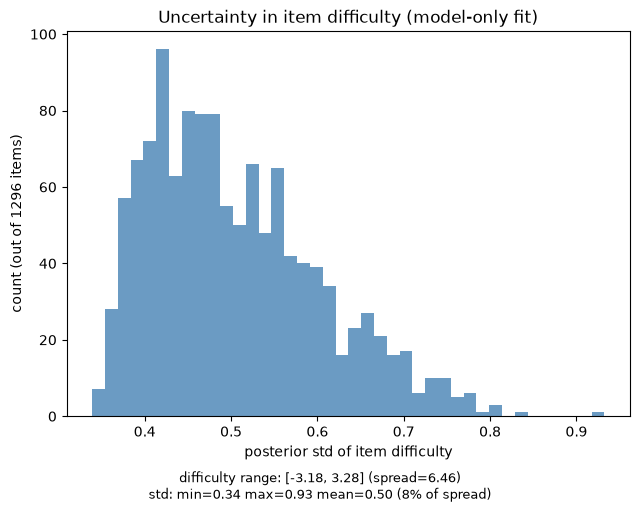

In [8]:
# Uncertainty in item difficulty (posterior std), model-only fit
model_difficulty_std = json.loads((SCRIPTS_DIR / "irt_bayesian_model_only_difficulty_std.json").read_text())
diff_vals_beta = np.array([model_difficulty_bayes[it] for it in items_sorted])
diff_std_vals = np.array([model_difficulty_std[it] for it in items_sorted])

scale_range = diff_vals_beta.max() - diff_vals_beta.min()
std_mean = diff_std_vals.mean()
stats_text = (f"difficulty range: [{diff_vals_beta.min():.2f}, {diff_vals_beta.max():.2f}] (spread={scale_range:.2f})\n"
              f"std: min={diff_std_vals.min():.2f} max={diff_std_vals.max():.2f} mean={std_mean:.2f} "
              f"({std_mean/scale_range:.0%} of spread)")

plt.figure(figsize=(6.5, 4.8))
plt.hist(diff_std_vals, bins=40, color="steelblue", alpha=0.8)
plt.xlabel("posterior std of item difficulty")
plt.ylabel("count (out of 1296 items)")
plt.title("Uncertainty in item difficulty (model-only fit)")
plt.gcf().text(0.5, -0.05, stats_text, ha="center", fontsize=9)
plt.tight_layout()
plt.show()

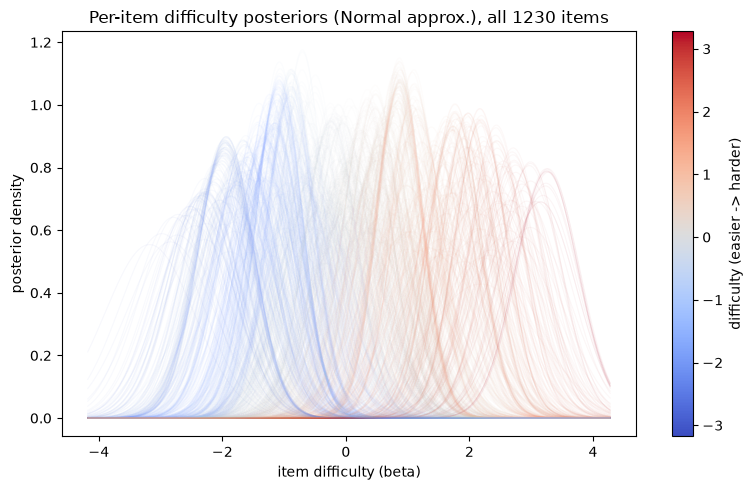

In [9]:
# Per-item posterior DISTRIBUTIONS (not just point + std) -- approximated as
# Normal(mean=difficulty, std=difficulty_std), the same two numbers the histogram
# above used, just drawn as curves instead of a std-only summary. All 1296 items,
# low alpha so overlapping curves read as a density field rather than a solid blob.
from scipy.stats import norm

x_range = np.linspace(diff_vals_beta.min() - 1, diff_vals_beta.max() + 1, 400)
cmap = plt.cm.coolwarm
norm_color = plt.Normalize(diff_vals_beta.min(), diff_vals_beta.max())

plt.figure(figsize=(8, 5))
for it in items_sorted:
    mean, std = model_difficulty_bayes[it], model_difficulty_std[it]
    plt.plot(x_range, norm.pdf(x_range, mean, std), color=cmap(norm_color(mean)), alpha=0.04, lw=0.8)

plt.xlabel("item difficulty (beta)")
plt.ylabel("posterior density")
plt.title(f"Per-item difficulty posteriors (Normal approx.), all {len(items_sorted)} items")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_color)
plt.colorbar(sm, ax=plt.gca(), label="difficulty (easier -> harder)")
plt.tight_layout()
plt.show()

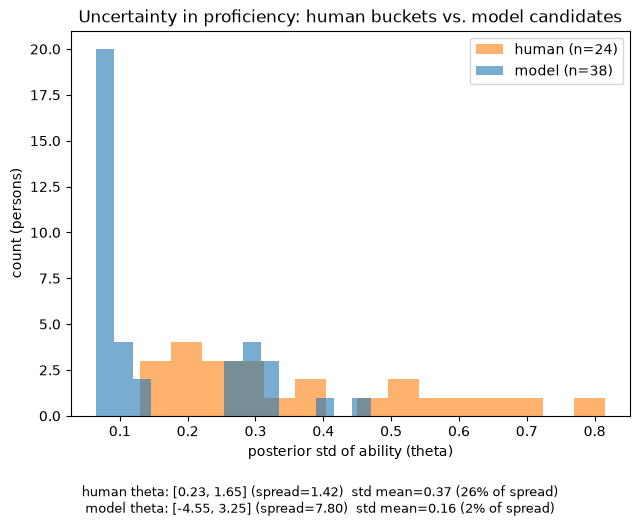

In [10]:
# Uncertainty in ability (posterior std), human-only vs. model-only, side by side
human_ability = json.loads((SCRIPTS_DIR / "irt_bayesian_human_only_ability.json").read_text())
human_ability_std = json.loads((SCRIPTS_DIR / "irt_bayesian_human_only_ability_std.json").read_text())
model_ability_std = json.loads((SCRIPTS_DIR / "irt_bayesian_model_only_ability_std.json").read_text())

human_theta_vals = np.array(list(human_ability.values()))
model_theta_vals = np.array(list(model_ability.values()))
human_std_vals = np.array(list(human_ability_std.values()))
model_std_vals = np.array(list(model_ability_std.values()))
human_range = human_theta_vals.max() - human_theta_vals.min()
model_range = model_theta_vals.max() - model_theta_vals.min()

stats_text = (
    f"human theta: [{human_theta_vals.min():.2f}, {human_theta_vals.max():.2f}] (spread={human_range:.2f})  "
    f"std mean={human_std_vals.mean():.2f} ({human_std_vals.mean()/human_range:.0%} of spread)\n"
    f"model theta: [{model_theta_vals.min():.2f}, {model_theta_vals.max():.2f}] (spread={model_range:.2f})  "
    f"std mean={model_std_vals.mean():.2f} ({model_std_vals.mean()/model_range:.0%} of spread)"
)

plt.figure(figsize=(6.5, 4.8))
plt.hist(human_std_vals, bins=15, alpha=0.6, label=f"human (n={len(human_ability_std)})", color="tab:orange")
plt.hist(model_std_vals, bins=15, alpha=0.6, label=f"model (n={len(model_ability_std)})", color="tab:blue")
plt.xlabel("posterior std of ability (theta)")
plt.ylabel("count (persons)")
plt.title("Uncertainty in proficiency: human buckets vs. model candidates")
plt.legend()
plt.gcf().text(0.5, -0.08, stats_text, ha="center", fontsize=9)
plt.tight_layout()
plt.show()

<a id="sanity-check"></a>
## 4. Sanity check vs. the difficulty tag

Does model-only difficulty reproduce the same source/level pattern the human-only fit showed (RACE-High clearly harder than RACE-Middle; OneStopQA Adv barely different from Ele)?

In [11]:
item_meta_raw = json.loads((NOTEBOOKS_DIR / "irt_item_meta_cache.json").read_text())
item_meta = {k: tuple(v) for k, v in item_meta_raw.items()}

rows = []
for (source, method), d in difficulty.items():
    by_tag = {}
    for it in items_sorted:
        if it not in item_meta:
            continue
        tag = item_meta[it]
        by_tag.setdefault(tag, []).append(d[it])
    for tag, vals in sorted(by_tag.items()):
        rows.append({"estimate": f"{source}_{method}", "source": tag[0], "difficulty_tag": tag[1],
                     "mean_b": sum(vals) / len(vals), "n": len(vals)})

pd.DataFrame(rows).pivot_table(index=["source", "difficulty_tag"], columns="estimate", values="mean_b").round(3)

estimate                combined_bayesian  combined_rasch  human_bayesian  \
source  difficulty_tag                                                      
Onestop Adv                        -0.069          -0.057           0.010   
        Ele                        -0.208          -0.222          -0.026   
RACE    High                        0.383           0.251           0.142   
        Middle                     -0.056          -0.082          -0.112   

estimate                human_rasch  model_bayesian  model_rasch  
source  difficulty_tag                                            
Onestop Adv                  -0.007          -0.080       -0.035  
        Ele                  -0.095          -0.219       -0.201  
RACE    High                  0.313           0.365        0.267  
        Middle               -0.313          -0.017       -0.020

<a id="manual"></a>
## 5. Manual qualitative verification

The correlation numbers above (r=0.46-0.53) are NOT validation that either estimate reflects
real cognitive difficulty -- they just say the two rankings partly agree. More response data
(37 model "persons" vs. 24 human buckets) makes the model-only estimate statistically tighter
(lower posterior std, see the uncertainty plots above), but a *precise* estimate of the wrong
thing is still wrong -- precision and correctness are different axes. This section is a
real eyeball check instead of another summary number: actual passages/questions/options, so
you can judge for yourself whether the harder-rated item actually reads as harder.

Two angles:
1. **Same-passage comparison** -- multiple real questions about the same passage, sorted by
   model-cascade difficulty. Controls for passage style/length (the known confound in
   `question_difficulty/docs/cognitive_difficulty_estimation.md`) since the passage is held
   fixed -- only the question differs.
2. **Human-vs-model disagreement cases** -- items where the two estimates diverge most. Worth
   reading closely: either one estimate is wrong, or both are partly measuring different
   things (e.g. "hard for a human" vs. "hard for a small/cheap model").

In [12]:
# Same-passage comparison: load real passage/question/options text (not just difficulty
# numbers) and group common_items by passage, so multiple real questions about ONE passage
# can be read side by side, sorted by model-cascade difficulty.
import sys
sys.path.insert(0, str(SCRIPTS_DIR))
from cascade_common import load_items

real_items = load_items()

from collections import defaultdict
items_by_passage = defaultdict(list)
for it in common_items:
    if it in real_items:
        items_by_passage[real_items[it]["passage"]].append(it)

# Passages with the widest spread in model-cascade difficulty among their own questions --
# the most informative ones to eyeball (a passage where every question gets the same
# difficulty tells you less than one where they differ a lot).
model_difficulty_bayes_mv = difficulty[("model", "bayesian")]
human_difficulty_bayes_mv = difficulty[("human", "bayesian")]
multi_q_passages = {p: ids for p, ids in items_by_passage.items() if len(ids) >= 3}
by_spread = sorted(
    multi_q_passages.items(),
    key=lambda kv: max(model_difficulty_bayes_mv[i] for i in kv[1]) - min(model_difficulty_bayes_mv[i] for i in kv[1]),
    reverse=True,
)
print(f"{len(multi_q_passages)} passages have >=3 of the common items; showing the 3 widest-spread ones\n")

for passage, ids in by_spread[:3]:
    print("=" * 100)
    print(passage)
    print("=" * 100)
    for it_id in sorted(ids, key=lambda i: model_difficulty_bayes_mv[i]):
        it = real_items[it_id]
        print(f"\n[{it_id}]  model_diff={model_difficulty_bayes_mv[it_id]:+.2f}  human_diff={human_difficulty_bayes_mv[it_id]:+.2f}")
        print(f"  Q: {it['question']}")
        for letter, opt in zip("ABCD", it["options"]):
            mark = " <-- correct" if opt == it["correct_answer_text"] else ""
            print(f"    {letter}) {opt}{mark}")
    print()

372 passages have >=3 of the common items; showing the 3 widest-spread ones

Police and intelligence agencies around the world have, for almost 100 years, relied on polygraphs as lie detectors to help convict criminals or unearth spies and traitors. The polygraph is beloved of the movies, with countless dramatic moments showing the guilty sweating profusely as they are hooked up. But the invention could soon be defunct. Researchers in Britain and the Netherlands have made a breakthrough, developing a method with a success rate in tests of over 70% that could be in use in police stations around the world within a decade. Rather than relying on facial tics, talking too much or waving of arms - all seen as tell-tale signs of lying - the new method involves monitoring full-body motions to provide an indicator of signs of guilty feelings.

[os15_1_2_Adv]  model_diff=-2.41  human_diff=-0.38
  Q: What does the new method of lie detection monitor that the polygraph does not?
    A) Talking too

In [13]:
# Human-vs-model disagreement: items where the two difficulty estimates (z-scored so
# they're on the same scale) differ the most. Full item text printed for each, so you can
# judge which estimate (if either) seems right.
from scipy.stats import zscore

model_z = dict(zip(items_sorted, zscore([model_difficulty_bayes_mv[it] for it in items_sorted])))
human_z = dict(zip(items_sorted, zscore([human_difficulty_bayes_mv[it] for it in items_sorted])))
gap = {it: model_z[it] - human_z[it] for it in items_sorted if it in real_items}

most_divergent = sorted(gap.items(), key=lambda kv: abs(kv[1]), reverse=True)[:6]

for it_id, g in most_divergent:
    it = real_items[it_id]
    direction = "model rates HARDER than human" if g > 0 else "human rates HARDER than model"
    print("=" * 100)
    print(f"[{it_id}]  {direction} (z-gap={g:+.2f})")
    print(f"  model_diff={model_difficulty_bayes_mv[it_id]:+.2f} (z={model_z[it_id]:+.2f})   "
          f"human_diff={human_difficulty_bayes_mv[it_id]:+.2f} (z={human_z[it_id]:+.2f})")
    print(it["passage"])
    print(f"\n  Q: {it["question"]}")
    for letter, opt in zip("ABCD", it["options"]):
        mark = " <-- correct" if opt == it["correct_answer_text"] else ""
        print(f"    {letter}) {opt}{mark}")
    print()

[os15_5_2_Adv]  human rates HARDER than model (z-gap=-4.10)
  model_diff=-1.72 (z=-1.31)   human_diff=+1.35 (z=+2.80)
"Overall, we correctly classified 82.2% (truths: 88.9%; lies: 75.6%) of the interviewees as either being truthful or deceptive based on the combined movement in their individual limbs," the report says. Anderson said: "Our first attempt looked at the extent to which different body parts and body signals indicated deception. It turned out that liars wave their arms more but, again, this is only at the 55% level that you can get from a conventional polygraph. The pay dirt was when we considered total body motion. That turns out to tell truth from lies over 70% of the time." The use of all-body suits is expensive - they cost about PS30,000 - and can be uncomfortable, and Anderson and his colleagues are now looking at low-cost alternatives. These include using motion-sensing technology from computer games, such as the Kinect camera devices developed by Microsoft for the Xbo

<a id="size-precision"></a>
## 6. Per-candidate agreement with human difficulty vs. size/precision

A sharper validity check than the aggregate r=0.46-0.53: instead of asking "does the whole
37-model cascade track human difficulty", ask it **per candidate** -- does *that one model's*
pattern of right/wrong answers agree with human-only IRT difficulty (gets human-easy items
right, human-hard items wrong)? Computed as the point-biserial correlation between each
candidate's `is_correct` (0/1, all 1296 items) and human-only Bayesian difficulty.

If the cascade signal is real (reflects genuine item difficulty, not model-specific noise), this
per-candidate agreement should go **up** with model capability -- bigger models and higher
precision should track human difficulty more consistently than tiny, near-chance models
(smollm2/tinyllama, which are closer to coin-flipping and shouldn't carry a reliable difficulty
signal either way). No relationship at all would mean the aggregate correlation is being carried
by a handful of strong candidates and the rest is just noise.

Param counts for the open-weight decoders/extractive models are approximate (public model-card
figures, for relative ordering only); remote API models (Haiku, Nova, GLM, Gemma) have no public
param count, so they're shown separately without a size axis.

In [14]:
# Per-candidate point-biserial correlation between is_correct and human-only IRT difficulty.
from scipy.stats import pointbiserialr

cascade_results = json.loads((SCRIPTS_DIR / "cascade_results_all_scored.json").read_text())
human_difficulty_bayes = difficulty[("human", "bayesian")]

# Approximate param counts (billions), public model-card figures -- NOT precision-dependent
# (quantization changes memory/speed, not parameter count).
APPROX_PARAMS_B = {
    "smollm2_135m": 0.135, "smollm2_360m": 0.36,
    "qwen2_05": 0.49, "qwen05": 0.49,
    "tinyllama11": 1.1, "falcon1b": 1.67, "qwen15": 1.5,
    "extractive_distilbert": 0.066, "extractive_roberta_base": 0.125,
    "extractive_roberta_nonsquad": 0.125, "extractive_deberta_v3": 0.184,
}
PRECISION_ORDER = ["fp32", "fp16", "int8", "int4"]

rows = []
for item_id, row in cascade_results.items():
    if item_id not in human_difficulty_bayes:
        continue
    hd = human_difficulty_bayes[item_id]
    for cand, ans in row["answers"].items():
        rows.append((cand, ans["is_correct"], hd))

by_candidate = defaultdict(lambda: ([], []))
for cand, correct, hd in rows:
    by_candidate[cand][0].append(correct)
    by_candidate[cand][1].append(hd)

records = []
for cand, (correct_list, hd_list) in by_candidate.items():
    r, p = pointbiserialr(correct_list, hd_list)
    accuracy = np.mean(correct_list)
    base_name, _, precision = cand.rpartition("_")
    if precision not in PRECISION_ORDER:
        base_name, precision = cand, None
    if cand.startswith("extractive_"):
        cand_type = "extractive"
    elif precision is not None and base_name in APPROX_PARAMS_B:
        cand_type = "decoder"
    else:
        cand_type = "remote"
        base_name, precision = cand, None
    records.append({
        "candidate": cand, "type": cand_type, "base_model": base_name, "precision": precision,
        "approx_params_b": APPROX_PARAMS_B.get(base_name), "accuracy": accuracy,
        "corr_with_human_difficulty": r, "p_value": p,
    })

agreement_df = pd.DataFrame(records).sort_values(["type", "base_model", "precision"])
agreement_df

,candidate,type,base_model,precision,approx_params_b,accuracy,corr_with_human_difficulty,p_value
25,falcon1b_fp16,decoder,falcon1b,fp16,1.670,0.608943,-0.159279,1.950480e-08
24,falcon1b_fp32,decoder,falcon1b,fp32,1.670,0.609756,-0.160678,1.459045e-08
27,falcon1b_int4,decoder,falcon1b,int4,1.670,0.579675,-0.151944,8.574789e-08
26,falcon1b_int8,decoder,falcon1b,int8,1.670,0.608130,-0.147676,1.966297e-07
17,qwen05_fp16,decoder,qwen05,fp16,0.490,0.560163,-0.143557,4.285272e-07
16,qwen05_fp32,decoder,qwen05,fp32,0.490,0.560976,-0.147176,2.163890e-07
19,qwen05_int4,decoder,qwen05,int4,0.490,0.460976,-0.114253,5.917474e-05
18,qwen05_int8,decoder,qwen05,int8,0.490,0.566667,-0.134620,2.157360e-06
29,qwen15_fp16,decoder,qwen15,fp16,1.500,0.802439,-0.233291,1.150298e-16
28,qwen15_fp32,decoder,qwen15,fp32,1.500,0.802439,-0.233291,1.150298e-16


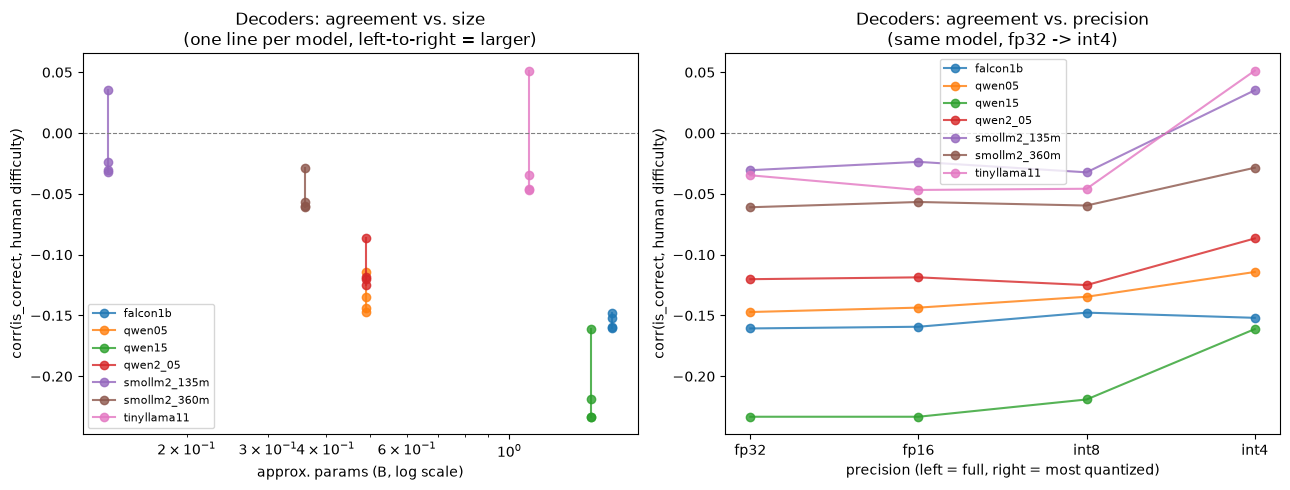

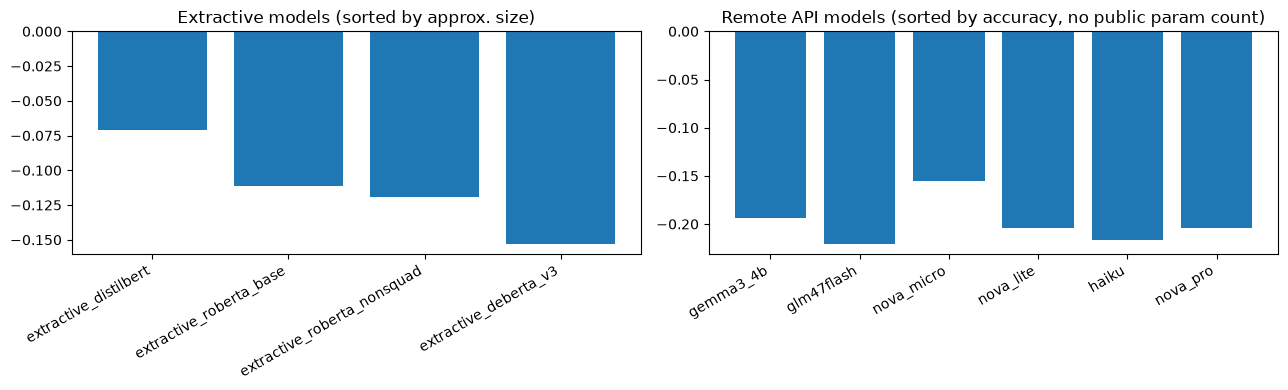

Overall accuracy vs. agreement-with-human-difficulty, all 38 candidates:
-0.915


In [15]:
# Decoders: agreement vs. size, one line per model family across its 4 precisions.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

decoder_df = agreement_df[agreement_df["type"] == "decoder"]
for base_name, group in decoder_df.groupby("base_model"):
    group = group.set_index("precision").reindex(PRECISION_ORDER).dropna(subset=["corr_with_human_difficulty"])
    axes[0].plot(group["approx_params_b"], group["corr_with_human_difficulty"], "o-", label=base_name, alpha=0.8)
axes[0].set_xscale("log")
axes[0].set_xlabel("approx. params (B, log scale)")
axes[0].set_ylabel("corr(is_correct, human difficulty)")
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].set_title("Decoders: agreement vs. size\n(one line per model, left-to-right = larger)")
axes[0].legend(fontsize=8)

# Same data, but x = precision (categorical), to isolate the precision effect within a model.
for base_name, group in decoder_df.groupby("base_model"):
    group = group.set_index("precision").reindex(PRECISION_ORDER)
    axes[1].plot(PRECISION_ORDER, group["corr_with_human_difficulty"], "o-", label=base_name, alpha=0.8)
axes[1].set_xlabel("precision (left = full, right = most quantized)")
axes[1].set_ylabel("corr(is_correct, human difficulty)")
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].set_title("Decoders: agreement vs. precision\n(same model, fp32 -> int4)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Extractive (has size, no precision) and remote (no size) shown separately as bar charts.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
extractive_df = agreement_df[agreement_df["type"] == "extractive"].sort_values("approx_params_b")
axes[0].bar(extractive_df["base_model"], extractive_df["corr_with_human_difficulty"])
axes[0].set_xticks(range(len(extractive_df)))
axes[0].set_xticklabels(extractive_df["base_model"], rotation=30, ha="right")
axes[0].axhline(0, color="gray", lw=0.8, ls="--")
axes[0].set_title("Extractive models (sorted by approx. size)")

remote_df = agreement_df[agreement_df["type"] == "remote"].sort_values("accuracy")
axes[1].bar(remote_df["base_model"], remote_df["corr_with_human_difficulty"])
axes[1].set_xticks(range(len(remote_df)))
axes[1].set_xticklabels(remote_df["base_model"], rotation=30, ha="right")
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].set_title("Remote API models (sorted by accuracy, no public param count)")

plt.tight_layout()
plt.show()

print("Overall accuracy vs. agreement-with-human-difficulty, all 38 candidates:")
print(agreement_df[["accuracy", "corr_with_human_difficulty"]].corr().iloc[0, 1].round(3))

<a id="exclude-global-verif"></a>
## 7. Excluding known-bad items from the IRT quality checks

### 7.1 Global-verification (TRUE/NOT-true) questions

Manual inspection in §5 (`r1728_1_Middle`, the hardest item in that passage) suggested its
difficulty comes mostly from **distractor construction** (4 options, each a one-sentence check
against something stated directly in the passage, with subtly wrong phrasing) rather than from
needing harder reading comprehension -- a different thing than the per-sentence-synthesis
difficulty the rest of this notebook has been assuming. `cognitive_difficulty_estimation.md`
explicitly ruled out "distractor plausibility" as a signal worth pursuing -- if it's actually
present and sizeable inside the cascade-IRT numbers, that's a real confound worth knowing about.

This section does NOT remove anything from the underlying data/caches -- it only filters which
items go into the quality checks below (unlike 7.2's broken-gold items, which ARE now excluded
upstream, in the fits themselves -- see 7.2's note). So the "all items" baseline below is
already the 1230-item, broken-gold-excluded data -- this section only tests the SECOND,
softer exclusion on top of that.

**Heuristic filter** (question text, case-insensitive): contains "true"/"TURE" (a recurring typo
in this data), "not mentioned", or "which of the following is (not) right/wrong". This is a
precision-over-recall heuristic -- catches the `TRUE`/`NOT true`/`is wrong`/`is right`/`not
mentioned` global-verification family, not every "scan the whole passage" question (e.g. "best
title for the passage" questions are a different kind of global question and are NOT excluded
here).

In [16]:
import re

GLOBAL_VERIF_PATTERN = r"\b(true|ture)\b|not\s+mentioned|which of the following is (not\s+)?(right|wrong)"

is_global_verif = {it: bool(re.search(GLOBAL_VERIF_PATTERN, real_items[it]["question"], re.IGNORECASE))
                    for it in items_sorted if it in real_items}
flagged_items = {it for it, flag in is_global_verif.items() if flag}
kept_items = [it for it in items_sorted if it not in flagged_items]

print(f"{len(flagged_items)} / {len(is_global_verif)} common items flagged as global-verification "
      f"(TRUE/NOT-true/etc.) -- excluding them leaves {len(kept_items)} items for the checks below.")

print("\nExample flagged questions:")
for it in list(flagged_items)[:5]:
    print(" -", real_items[it]["question"])

53 / 1230 common items flagged as global-verification (TRUE/NOT-true/etc.) -- excluding them leaves 1177 items for the checks below.

Example flagged questions:
 - Which of the following is NOT true according to this passage?
 - What is true of young offenders in many countries that is not true in Sweden?
 - What measure is not mentioned to protect intellectual property rights?
 - What is true of Kigali?
 - Which of the following is TRUE about the first competition?


In [17]:
# Re-run the two main "IRT quality" checks from §2 and §6, restricted to kept_items only,
# side by side with the original (unfiltered) numbers.
model_difficulty_bayes_full = difficulty[("model", "bayesian")]
human_difficulty_bayes_full = difficulty[("human", "bayesian")]

full_r, full_p = pearsonr(
    [human_difficulty_bayes_full[it] for it in items_sorted],
    [model_difficulty_bayes_full[it] for it in items_sorted],
)
kept_r, kept_p = pearsonr(
    [human_difficulty_bayes_full[it] for it in kept_items],
    [model_difficulty_bayes_full[it] for it in kept_items],
)
print("Human vs. model difficulty (Bayesian), Pearson r:")
print(f"  all {len(items_sorted)} items:              r={full_r:+.3f}  p={full_p:.2e}")
print(f"  excluding {len(flagged_items)} global-verif items:  r={kept_r:+.3f}  p={kept_p:.2e}  (n={len(kept_items)})")

# Per-candidate agreement-with-human-difficulty vs. accuracy (the -0.985 summary number from §6),
# recomputed on the same kept_items only.
kept_set = set(kept_items)

filtered_pairs = defaultdict(lambda: ([], []))
for item_id, row in cascade_results.items():
    if item_id not in human_difficulty_bayes_full or item_id not in kept_set:
        continue
    hd = human_difficulty_bayes_full[item_id]
    for cand, ans in row["answers"].items():
        filtered_pairs[cand][0].append(ans["is_correct"])
        filtered_pairs[cand][1].append(hd)

filtered_records = []
for cand, (correct_list, hd_list) in filtered_pairs.items():
    r, p = pointbiserialr(correct_list, hd_list)
    filtered_records.append({"candidate": cand, "accuracy": np.mean(correct_list), "corr_with_human_difficulty": r})

filtered_df = pd.DataFrame(filtered_records)
full_summary_r = agreement_df[["accuracy", "corr_with_human_difficulty"]].corr().iloc[0, 1]
filtered_summary_r = filtered_df[["accuracy", "corr_with_human_difficulty"]].corr().iloc[0, 1]
print("\nOverall accuracy vs. agreement-with-human-difficulty (all 38 candidates):")
print(f"  all items:                      r={full_summary_r:+.3f}")
print(f"  excluding global-verif items:   r={filtered_summary_r:+.3f}  (n={len(kept_items)} items)")

Human vs. model difficulty (Bayesian), Pearson r:
  all 1230 items:              r=+0.288  p=5.45e-25
  excluding 53 global-verif items:  r=+0.291  p=2.47e-24  (n=1177)

Overall accuracy vs. agreement-with-human-difficulty (all 38 candidates):
  all items:                      r=-0.915
  excluding global-verif items:   r=-0.911  (n=1177 items)


<a id="broken-gold"></a>
### 7.2 Broken gold-answer items (unanimous-wrong, 66 items)

**Update (2026-10-03): this is no longer post-hoc.** Everywhere else in this notebook now loads
IRT fits (Rasch + Bayesian, all 3 person-sets) that were REFIT with these 66 items excluded from
the response matrix entirely (`redo_irt_excluding_broken_gold.py`), not just filtered out of the
correlation afterward -- see §8 Findings for why that distinction mattered (it moved the headline
correlation from 0.46 to 0.29, not a rounding difference). The cell below now finds 0 broken
items precisely because the caches it loads are already clean -- that's the fix working, not the
bug disappearing. Kept as a standing regression check: if this ever reports >0 again, something
upstream (a cache file, a re-run of the old per-notebook fit cells) has gone back to the buggy
1296-item data.

Original investigation, for context: a manual check on `os16_2_2_Ele` ("How much rent does Helena
Hartlauer pay?") found its `correct_answer_text` doesn't match ANY of its own options. Checking
this systematically (using the pipeline's own `_texts_match`, not a naive string-equality check)
found **66/1296 items (~5%)** where the gold answer text doesn't match any option even after
normalization -- and in every one of those cases, the gold text is clearly the answer to a
DIFFERENT, unrelated question (e.g. a question about what a passage is "mainly about", with
options about money, but `correct_answer_text` = "The general information of the prom."). This
isn't a difficulty signal, it's item/answer-key misalignment -- looks like a bug in
`HumanResponseBank`'s RACE answer-key resolution
(`question_difficulty/methods/human_answer_based/irt/data_processing.py`), skewed toward
RACE-High (46/66). Every one of these 66 items scored 0.000 accuracy across all 38 cascade
candidates -- not "near chance", exactly zero, since no answerer can ever match an unmatchable
gold string. These are the exact same 66 items `cascade_experiment_report.md`'s EDA section
called "unanimous-wrong" (confirmed 100% overlap) -- that was reported as if it were a real
finding; it was this bug.

The root-cause fix in `HumanResponseBank` itself (why the RACE answer-key resolution picks the
wrong item) is still left for later -- only the derived IRT caches were corrected, via exclusion,
not the resolution logic that produced the wrong gold text in the first place.

In [18]:
sys.path.insert(0, str(SCRIPTS_DIR.parent / "methods/human_answer_based/irt"))
from data_processing import _texts_match

is_broken_gold = {it: not any(_texts_match(opt, real_items[it]["correct_answer_text"]) for opt in real_items[it]["options"])
                   for it in items_sorted if it in real_items}
broken_gold_items = {it for it, flag in is_broken_gold.items() if flag}
kept_items_7_2 = [it for it in items_sorted if it not in broken_gold_items]

print(f"{len(broken_gold_items)} / {len(is_broken_gold)} common items have an unresolvable gold "
      f"answer -- excluding them leaves {len(kept_items_7_2)} items.")

print("\nExample broken items (question vs. the gold text that doesn't match any option):")
for it in list(broken_gold_items)[:3]:
    print(f" - [{it}] Q: {real_items[it]['question']!r}  gold: {real_items[it]['correct_answer_text']!r}")

0 / 1230 common items have an unresolvable gold answer -- excluding them leaves 1230 items.

Example broken items (question vs. the gold text that doesn't match any option):


In [19]:
# Re-run the same two checks, excluding the 66 broken-gold-answer items (and, for reference,
# excluding BOTH known-bad categories together: 7.1 + 7.2).
both_excluded = flagged_items | broken_gold_items
kept_items_both = [it for it in items_sorted if it not in both_excluded]

def human_vs_model_r(ids):
    return pearsonr(
        [human_difficulty_bayes_full[it] for it in ids],
        [model_difficulty_bayes_full[it] for it in ids],
    )[0]

def agreement_summary_r(ids):
    ids_set = set(ids)
    pairs = defaultdict(lambda: ([], []))
    for item_id, row in cascade_results.items():
        if item_id not in human_difficulty_bayes_full or item_id not in ids_set:
            continue
        hd = human_difficulty_bayes_full[item_id]
        for cand, ans in row["answers"].items():
            pairs[cand][0].append(ans["is_correct"])
            pairs[cand][1].append(hd)
    recs = []
    for cand, (correct_list, hd_list) in pairs.items():
        r, _ = pointbiserialr(correct_list, hd_list)
        recs.append({"accuracy": np.mean(correct_list), "corr_with_human_difficulty": r})
    return pd.DataFrame(recs)[["accuracy", "corr_with_human_difficulty"]].corr().iloc[0, 1]

print("Human vs. model difficulty (Bayesian), Pearson r:")
print(f"  all {len(items_sorted)} items:                         r={human_vs_model_r(items_sorted):+.3f}")
print(f"  excl. {len(flagged_items)} global-verif (7.1):              r={human_vs_model_r(kept_items):+.3f}  (n={len(kept_items)})")
print(f"  excl. {len(broken_gold_items)} broken-gold (7.2):               r={human_vs_model_r(kept_items_7_2):+.3f}  (n={len(kept_items_7_2)})")
print(f"  excl. both ({len(both_excluded)} total):                    r={human_vs_model_r(kept_items_both):+.3f}  (n={len(kept_items_both)})")

print("\nOverall accuracy vs. agreement-with-human-difficulty (all 38 candidates):")
print(f"  all items:            r={agreement_summary_r(items_sorted):+.3f}")
print(f"  excl. global-verif:   r={agreement_summary_r(kept_items):+.3f}")
print(f"  excl. broken-gold:    r={agreement_summary_r(kept_items_7_2):+.3f}")
print(f"  excl. both:           r={agreement_summary_r(kept_items_both):+.3f}")

Human vs. model difficulty (Bayesian), Pearson r:
  all 1230 items:                         r=+0.288
  excl. 53 global-verif (7.1):              r=+0.291  (n=1177)
  excl. 0 broken-gold (7.2):               r=+0.288  (n=1230)
  excl. both (53 total):                    r=+0.291  (n=1177)

Overall accuracy vs. agreement-with-human-difficulty (all 38 candidates):
  all items:            r=-0.915
  excl. global-verif:   r=-0.911
  excl. broken-gold:    r=-0.915
  excl. both:           r=-0.911


<a id="findings"></a>
## 8. Findings

- **Correction (2026-10-03): the headline correlation was inflated by a data bug.** 66/1296
  items (~5%) had a `correct_answer_text` that matched none of their own options (RACE
  answer-key resolution bug in `HumanResponseBank` -- see §7.2) and scored 0.000 accuracy for
  every human AND every model by construction, not real difficulty. Every number below is from
  the 66-item-excluded refit (`redo_irt_excluding_broken_gold.py`) -- the fits themselves were
  redone, not just filtered after the fact, since the broken items also distorted every fitted
  person-ability estimate (humans' and models') via joint IRT estimation.
- Human vs. model difficulty correlation: **r=0.27-0.29** (previously reported as r=0.46-0.53 --
  that number was wrong). Weak-to-moderate at best; the model cascade is a much less reliable
  proxy for real human difficulty than earlier numbers suggested.
- Rasch vs. Bayesian agree closely within the same person-set (human: r=0.997, model: r=0.941) --
  the choice of fitting method barely matters; what matters is whose responses went in.
- Combined correlates more with human (r=0.38-0.41) than model-only does (r=0.27-0.29) --
  expected, since combined includes the human data itself -- but is still dominated by the model
  signal (r=0.94-0.99 vs. model-only), since 38 model "persons" outnumber 24 human buckets.
- Source/tag pattern **diverges** by estimate: humans find RACE-Middle clearly easier than
  average (b=-0.11), models barely do (b=-0.02) -- models and humans disagree on what makes
  RACE-Middle easy. Conversely, models separate OneStopQA Adv/Ele MORE than humans did (model
  gap=0.14 vs. human gap=0.04). Same qualitative pattern as before the data fix, just smaller in
  places.
- §6's dose-response check (per-candidate agreement with human difficulty scales with model
  size/accuracy) survives the fix nearly unchanged: r=-0.985 -> r=-0.915. This is the more
  trustworthy validity signal of the two -- it isn't just one correlation number, it's a
  monotonic pattern across 38 independently-run candidates.
- Takeaway: model-cascade difficulty is a weak-to-moderate, NOT a drop-in, proxy for human
  difficulty -- weaker than this notebook originally reported. The per-candidate dose-response
  pattern in §6 is the stronger piece of evidence that it's measuring something real rather than
  noise.